# Synthetic RM/PM Data Generation: Methods, Proof And Workflow Suitability

This standalone notebook provides evaluator-facing proof of how the project-operational dataset was generated. It documents the technologies, equations, stochastic distributions, causal relationships, validation checks, plots, reproducibility controls and WMS table mapping.

**Claim boundary:** this is a seeded controlled simulation with known ground truth. It validates software integration and whether forecasting methods can recover a known process. It does not prove accuracy on an external warehouse and must not be described as observed customer history.


In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name != "v8_controlled_synthetic_validation":
    candidate = ROOT / "Ai miroservices/modeling/v8_controlled_synthetic_validation"
    ROOT = candidate if candidate.exists() else ROOT
sys.path.insert(0, str(ROOT))
from pipeline.generate_data import SimulationConfig, generate_controlled_dataset

OUT = ROOT / "outputs"
DATA = OUT / "data"
summary = json.loads((OUT / "run_summary.json").read_text())
cfg = SimulationConfig()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
cfg


SimulationConfig(seed=20260711, months=72, fg_count=24, rm_count=90, pm_count=30, start_month='2020-01-01')

## 1. Technologies And Randomness

- **NumPy `Generator`** supplies deterministic pseudo-random draws from a fixed seed (`20260711`). NumPy's generator provides an auditable, reproducible random stream; it is not an LLM or an undocumented data generator.
- **Pandas** builds relational tables and performs the FG-to-component BOM explosion.
- **Sinusoidal seasonal profiles** represent annual periodicity with randomized phase and amplitude.
- **Lognormal distributions** generate positive, right-skewed costs, BOM quantities and multiplicative operational variation.
- **Bernoulli events** generate promotions and rare disruptions/surges.
- **Autoregressive carryover** links current actual production to the previous month, preventing independent random months.
- **Structural interventions** introduce persistent level changes.
- **Heteroscedastic noise** increases absolute uncertainty with material demand scale.

These methods are suitable for a controlled WMS benchmark because their parameters are explicit, causal relationships are known, and the entire dataset is reproducible. They are not a substitute for estimating real-site distributions from observed data.


In [2]:
technology_register = pd.DataFrame([
    ["Reproducibility", "NumPy seeded Generator", cfg.seed, "Repeatable complete dataset"],
    ["Seasonality", "1 + A sin(2*pi*m/12 + phase)", "A ~ U(0.05, 0.28)", "Annual FG demand pattern"],
    ["Trend", "Compound annual trend", "r ~ U(-0.04, 0.12)", "Growth and decline"],
    ["Promotion", "Bernoulli event", "p = 0.11; multiplier 1.18", "Known demand uplift"],
    ["Holiday", "Calendar intervention", "months 1, 4, 12; multiplier 0.88", "Planned shutdown/slowdown"],
    ["Structural shift", "Persistent level intervention", "start month U(42,58); factor U(0.78,1.30)", "Regime change"],
    ["Rare shock", "Bernoulli plus discrete severity", "p = 0.035; {0.45,0.60,1.55,1.90}", "Disruption or surge"],
    ["Actual production", "Autoregressive causal equation", "0.55 plan + 0.25 lag actual + 0.20 shocked plan", "Plan deviation and persistence"],
    ["RM/PM demand", "BOM explosion", "FG actual * qty * (1+scrap) / yield", "Material requirements"],
    ["Process error", "Scale-dependent additive noise", "sigma grows with requirement", "Heteroscedastic consumption"],
], columns=["Purpose", "Method", "Parameters", "Workflow meaning"])
technology_register


,Purpose,Method,Parameters,Workflow meaning
0,Reproducibility,NumPy seeded Generator,20260711,Repeatable complete dataset
1,Seasonality,1 + A sin(2*pi*m/12 + phase),"A ~ U(0.05, 0.28)",Annual FG demand pattern
2,Trend,Compound annual trend,"r ~ U(-0.04, 0.12)",Growth and decline
3,Promotion,Bernoulli event,p = 0.11; multiplier 1.18,Known demand uplift
4,Holiday,Calendar intervention,"months 1, 4, 12; multiplier 0.88",Planned shutdown/slowdown
5,Structural shift,Persistent level intervention,"start month U(42,58); factor U(0.78,1.30)",Regime change
6,Rare shock,Bernoulli plus discrete severity,"p = 0.035; {0.45,0.60,1.55,1.90}",Disruption or surge
7,Actual production,Autoregressive causal equation,0.55 plan + 0.25 lag actual + 0.20 shocked plan,Plan deviation and persistence
8,RM/PM demand,BOM explosion,FG actual * qty * (1+scrap) / yield,Material requirements
9,Process error,Scale-dependent additive noise,sigma grows with requirement,Heteroscedastic consumption


## 2. Data-Generating Equations

For finished good (i), month (t):

\[
P_{i,t}=B_i(1+r_i)^{t/12}S_{i,m(t)}I^{promo}_{i,t}I^{holiday}_tI^{shift}_{i,t}\epsilon^{plan}_{i,t}
\]

\[
A_{i,t}=\left(0.55P_{i,t}+0.25A_{i,t-1}+0.20P_{i,t}K_{i,t}\right)\epsilon^{actual}_{i,t}
\]

For material (j), BOM component relation (q_{ij}), scrap (s_{ij}), and yield (y_{ij}):

\[
R_{j,t}=\sum_i A_{i,t}q_{ij}\frac{1+s_{ij}}{y_{ij}}
\]

Observed simulated issue demand is (D_{j,t}=\max(0,R_{j,t}+e_{j,t})), where the variance of (e_{j,t}) increases with (R_{j,t}). This deliberately creates the high-volume error behavior seen in real inventory systems without claiming that its fitted parameters came from a real warehouse.


In [3]:
materials = pd.read_csv(DATA / "materials.csv")
fg = pd.read_csv(DATA / "finished_goods.csv")
bom = pd.read_csv(DATA / "bom_components.csv")
production = pd.read_csv(DATA / "production_plan_actuals.csv", parse_dates=["month"])
demand = pd.read_csv(DATA / "material_demand.csv", parse_dates=["month"])
initial = pd.read_csv(DATA / "initial_inventory.csv")

table_register = pd.DataFrame([
    ["materials.csv", len(materials), "Material master, MOQ, order multiple, lead time, cost, service level", "materials"],
    ["finished_goods.csv", len(fg), "FG base demand, trend and volatility parameters", "materials (type=product)"],
    ["bom_components.csv", len(bom), "Effective component quantities, scrap and yield", "bom_headers + bom_components"],
    ["production_plan_actuals.csv", len(production), "Monthly FG plan, actual, promotion, holiday and shock state", "planning evidence"],
    ["material_demand.csv", len(demand), "Monthly exploded RM/PM requirement and issue demand", "demand_history"],
    ["initial_inventory.csv", len(initial), "Starting stock and replenishment constraints", "inventory"],
], columns=["Generated table", "Rows", "Role", "WMS destination"])
table_register


,Generated table,Rows,Role,WMS destination
0,materials.csv,120,"Material master, MOQ, order multiple, lead tim...",materials
1,finished_goods.csv,24,"FG base demand, trend and volatility parameters",materials (type=product)
2,bom_components.csv,211,"Effective component quantities, scrap and yield",bom_headers + bom_components
3,production_plan_actuals.csv,1728,"Monthly FG plan, actual, promotion, holiday an...",planning evidence
4,material_demand.csv,8640,Monthly exploded RM/PM requirement and issue d...,demand_history
5,initial_inventory.csv,120,Starting stock and replenishment constraints,inventory


## 3. Parameter And Master-Data Distributions

Discrete operational values are used for MOQ/order multiples because purchasing constraints are not continuous. Lead times are bounded at 5-45 days. Costs are right-skewed and positive. The service-level choices are explicit policy scenarios, not estimated customer service levels.


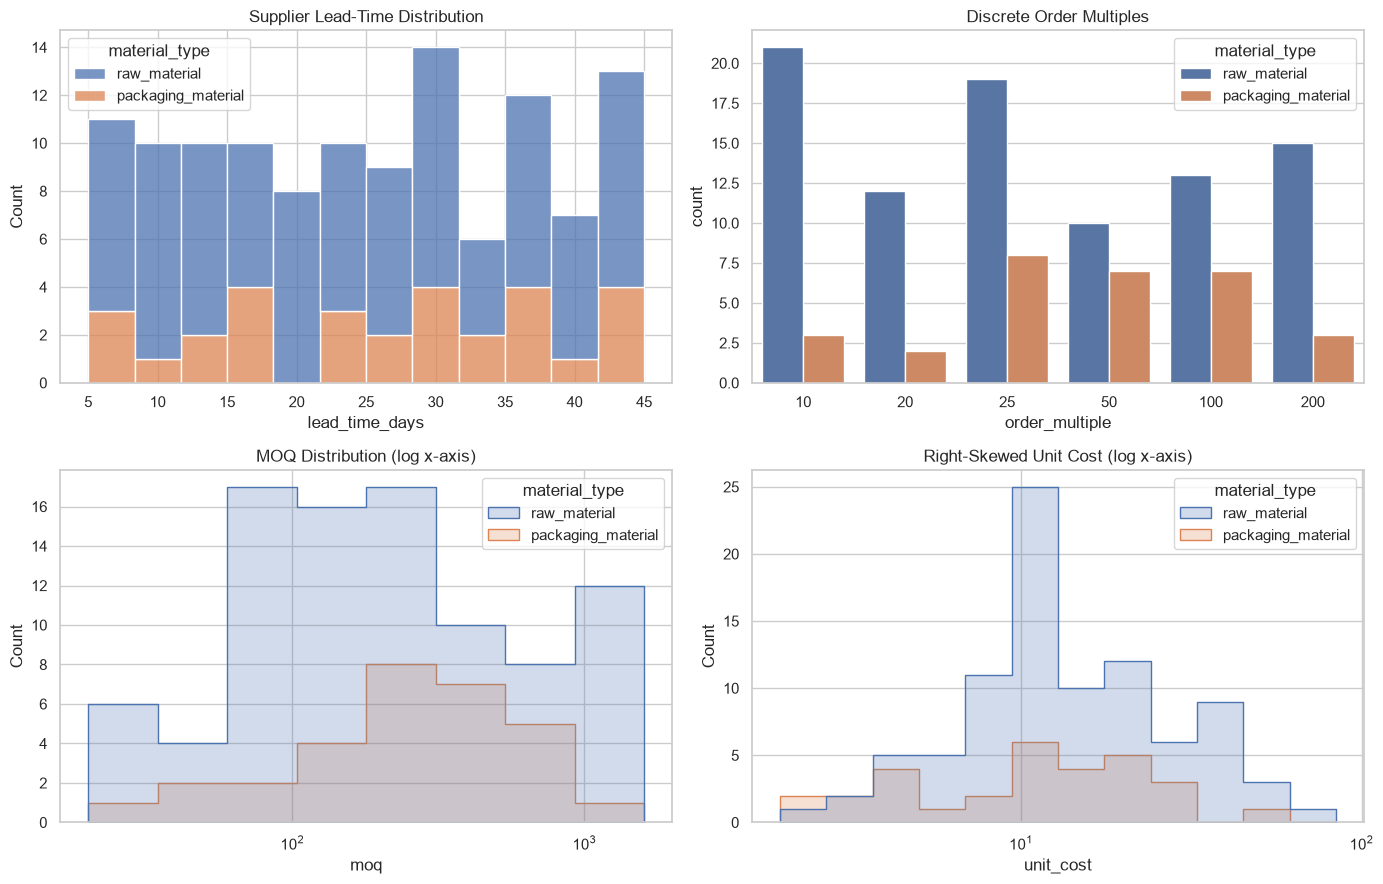

moq                                                      \
                   count    mean     std   min     25%    50%    75%     max   
material_type                                                                  
packaging_material  30.0  344.67  264.45  30.0  156.25  237.5  450.0  1000.0   
raw_material        90.0  356.33  388.83  20.0   92.50  190.0  500.0  1600.0   

                   order_multiple                                         \
                            count   mean    std   min   25%   50%    75%   
material_type                                                              
packaging_material           30.0  64.00  55.93  10.0  25.0  50.0  100.0   
raw_material                 90.0  63.61  67.84  10.0  20.0  25.0  100.0   

                          lead_time_days                                       \
                      max          count   mean    std  min   25%   50%   75%   
material_type                                                                   
packaging_material  200.0           30.0  26.47  11.81  7.0  17.0  27.5  35.0   
raw_material        200.0           90.0  24.44  11.98  5.0  14.0  23.5  35.5   

                         unit_cost                                          \
                     max     count   mean    std   min   25%    50%    75%   
material_type                                                                
packaging_material  45.0      30.0  13.79  10.29  1.96  5.04  11.56  19.31   
raw_material        45.0      90.0  17.48  13.71  2.57  9.17  12.49  21.82   

                           
                      max  
material_type              
packaging_material  50.11  
raw_material        84.08

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(materials, x="lead_time_days", hue="material_type", multiple="stack", bins=12, ax=axes[0,0])
axes[0,0].set_title("Supplier Lead-Time Distribution")
sns.countplot(materials, x="order_multiple", hue="material_type", ax=axes[0,1])
axes[0,1].set_title("Discrete Order Multiples")
sns.histplot(materials, x="moq", hue="material_type", element="step", log_scale=True, ax=axes[1,0])
axes[1,0].set_title("MOQ Distribution (log x-axis)")
sns.histplot(materials, x="unit_cost", hue="material_type", element="step", log_scale=True, ax=axes[1,1])
axes[1,1].set_title("Right-Skewed Unit Cost (log x-axis)")
plt.tight_layout()
plt.show()
materials.groupby("material_type")[["moq", "order_multiple", "lead_time_days", "unit_cost"]].describe().round(2)


## 4. BOM Topology And Coverage Proof

Each FG initially draws 4-8 RM and 1-3 PM components without replacement. A deterministic coverage repair then attaches any unused material to one FG. This guarantees controlled component coverage for testing BOM explosion; it must not be confused with a naturally observed BOM network.


,check,value,expected
0,FG parents covered,24,24
1,RM/PM components covered,120,120
2,unique BOM relations,211,211
3,duplicate FG-component keys,0,0


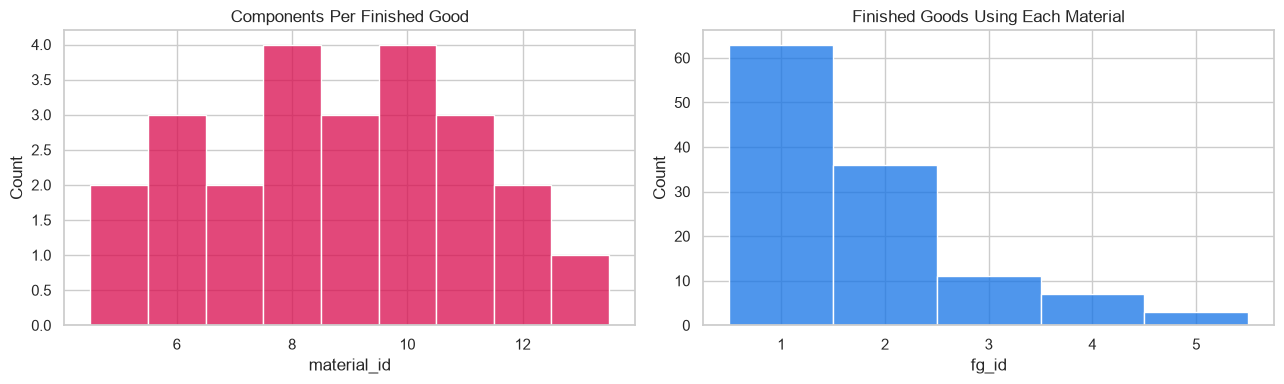

In [5]:
fg_degree = bom.groupby("fg_id")["material_id"].nunique()
material_degree = bom.groupby("material_id")["fg_id"].nunique()
coverage = pd.DataFrame({
    "check": ["FG parents covered", "RM/PM components covered", "unique BOM relations", "duplicate FG-component keys"],
    "value": [bom.fg_id.nunique(), bom.material_id.nunique(), len(bom), bom.duplicated(["fg_id", "material_id"]).sum()],
    "expected": [len(fg), len(materials), len(bom), 0],
})
display(coverage)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(fg_degree, discrete=True, ax=axes[0], color="#d90b4d")
axes[0].set_title("Components Per Finished Good")
sns.histplot(material_degree, discrete=True, ax=axes[1], color="#1473e6")
axes[1].set_title("Finished Goods Using Each Material")
plt.tight_layout(); plt.show()


## 5. Production Dynamics: Plan, Actual, Seasonality And Events

The plan is known at forecast creation time in the controlled causal experiment. Actual production deviates through persistence, multiplicative variation and rare shocks. This distinction prevents using future actual production as a feature.


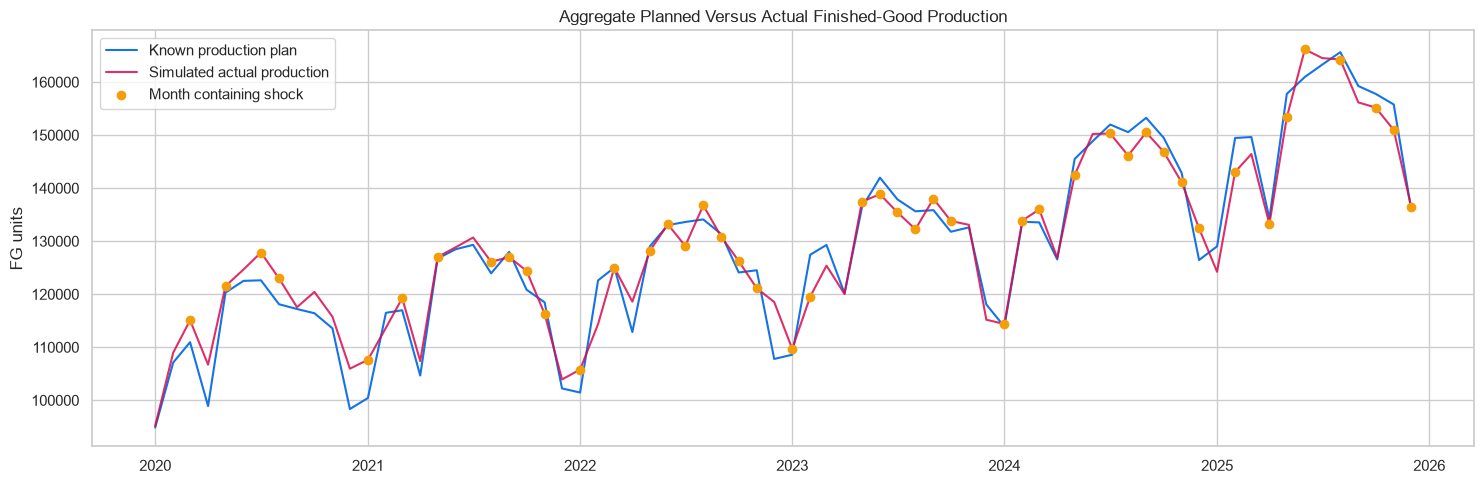

,rows,mean_plan,mean_actual
shock_type,,,
disruption,32,5354.21,4984.92
none,1665,5354.76,5360.29
surge,31,6477.27,7159.50


In [6]:
monthly = production.groupby("month", as_index=False).agg(
    planned=("planned_fg_units", "sum"), actual=("actual_fg_units", "sum"),
    promotions=("promotion_flag", "sum"), shocks=("shock_type", lambda x: (x != "none").sum()),
)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly.month, monthly.planned, label="Known production plan", color="#1473e6")
ax.plot(monthly.month, monthly.actual, label="Simulated actual production", color="#d90b4d", alpha=.85)
shock_months = monthly.loc[monthly.shocks.gt(0)]
ax.scatter(shock_months.month, shock_months.actual, label="Month containing shock", color="#f59e0b", zorder=3)
ax.set_title("Aggregate Planned Versus Actual Finished-Good Production")
ax.set_ylabel("FG units"); ax.legend(); plt.tight_layout(); plt.show()
production.groupby("shock_type").agg(rows=("fg_id","size"), mean_plan=("planned_fg_units","mean"), mean_actual=("actual_fg_units","mean")).round(2)


## 6. Material Demand, Scale And Heteroscedasticity

Raw and packaging demand is not sampled independently. It is caused by FG production and the BOM. The final process error is scale dependent, so large-volume materials have larger absolute errors even when relative error is reasonable.


,requirement_band,rows,mean_requirement,error_std,mean_abs_error
0,Q1,1728,851.98,28.81,20.97
1,Q2,1728,2470.72,73.93,58.00
2,Q3,1728,4650.32,139.83,110.39
3,Q4,1728,8926.24,260.30,205.27
4,Q5,1728,21568.80,784.33,535.82


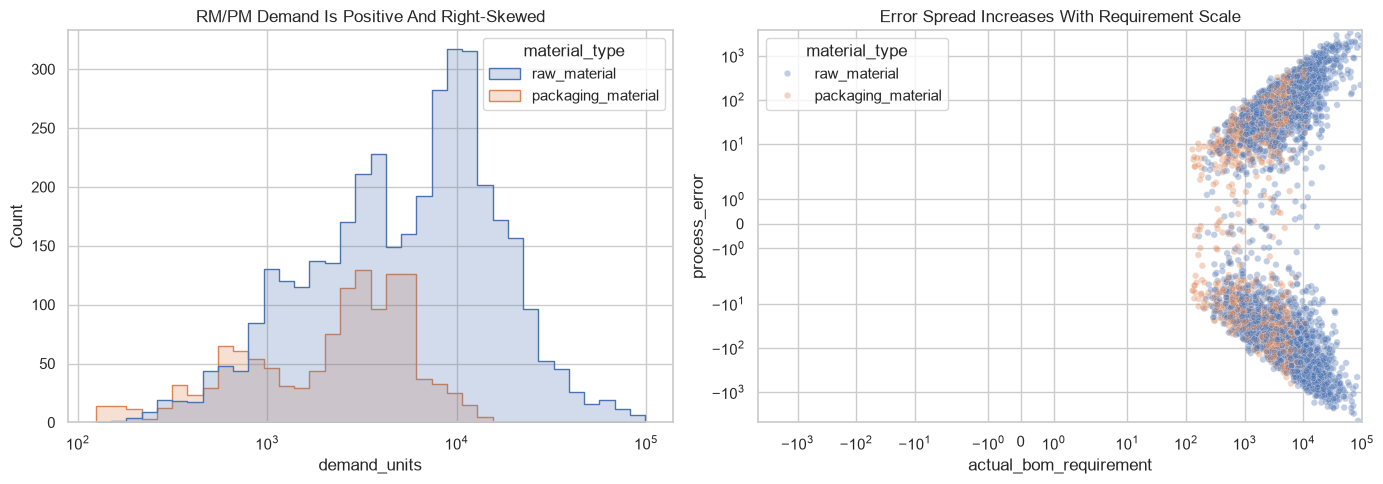

In [7]:
demand["process_error"] = demand["demand_units"] - demand["actual_bom_requirement"]
demand["requirement_band"] = pd.qcut(demand["actual_bom_requirement"].rank(method="first"), 5, labels=["Q1","Q2","Q3","Q4","Q5"])
band = demand.groupby("requirement_band", observed=True).agg(
    rows=("material_id","size"), mean_requirement=("actual_bom_requirement","mean"),
    error_std=("process_error","std"), mean_abs_error=("process_error", lambda s: s.abs().mean()),
).reset_index()
display(band.round(2))
sample = demand.sample(min(5000, len(demand)), random_state=cfg.seed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sample, x="demand_units", hue="material_type", element="step", log_scale=True, ax=axes[0])
axes[0].set_title("RM/PM Demand Is Positive And Right-Skewed")
sns.scatterplot(sample, x="actual_bom_requirement", y="process_error", hue="material_type", alpha=.35, s=22, ax=axes[1])
axes[1].set_xscale("symlog"); axes[1].set_yscale("symlog")
axes[1].set_title("Error Spread Increases With Requirement Scale")
plt.tight_layout(); plt.show()


## 7. Temporal Dependence And Intermittency

A warehouse history should not be independent rows. Lag correlation comes from production carryover and repeated BOM usage. Intermittency appears when materials are attached to fewer active FGs or when their exploded requirement is zero.


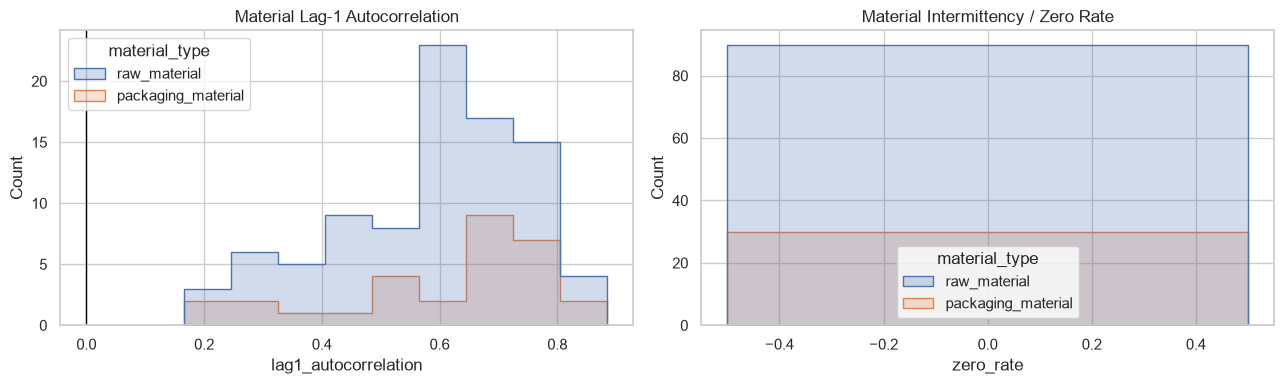

lag1_autocorrelation                                     \
                                  count   mean    std    min    25%    50%   
material_type                                                                
packaging_material                 30.0  0.606  0.190  0.172  0.511  0.669   
raw_material                       90.0  0.583  0.166  0.165  0.486  0.615   

                                 zero_rate                                     \
                      75%    max     count mean  std  min  25%  50%  75%  max   
material_type                                                                   
packaging_material  0.763  0.860      30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
raw_material        0.698  0.884      90.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                   mean_demand                                          \
                         count      mean        std      min       25%   
material_type                                                            
packaging_material        30.0  3261.059   2552.889  177.344  1003.068   
raw_material              90.0  9167.952  10094.909  309.590  2505.686   

                                                    
                         50%        75%        max  
material_type                                       
packaging_material  2904.206   4706.045  10104.307  
raw_material        7405.490  11336.521  67723.139

In [8]:
temporal = []
for material_id, group in demand.sort_values("month").groupby("material_id"):
    temporal.append({
        "material_id": material_id,
        "lag1_autocorrelation": group.demand_units.autocorr(1),
        "zero_rate": group.demand_units.eq(0).mean(),
        "mean_demand": group.demand_units.mean(),
    })
temporal = pd.DataFrame(temporal).merge(materials[["material_id","material_type"]], on="material_id")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(temporal, x="lag1_autocorrelation", hue="material_type", element="step", ax=axes[0])
axes[0].axvline(0, color="black", lw=1); axes[0].set_title("Material Lag-1 Autocorrelation")
sns.histplot(temporal, x="zero_rate", hue="material_type", element="step", ax=axes[1])
axes[1].set_title("Material Intermittency / Zero Rate")
plt.tight_layout(); plt.show()
temporal.groupby("material_type")[["lag1_autocorrelation","zero_rate","mean_demand"]].describe().round(3)


## 8. Integrity, Leakage And Reproducibility Proof

The fixed seed must regenerate identical CSV bytes under the same code/library behavior. The model protocol must use demand lags only through `t-1`; current-month production plan may be used only by explicitly causal candidates. Future actual production and target-month actual material demand are forbidden features.


In [9]:
integrity = {
    "months": int(demand.month.nunique()),
    "material_month_rows": int(len(demand)),
    "expected_material_month_rows": int(cfg.months * (cfg.rm_count + cfg.pm_count)),
    "negative_demand_rows": int(demand.demand_units.lt(0).sum()),
    "duplicate_material_month_keys": int(demand.duplicated(["material_id","month"]).sum()),
    "bom_parent_coverage_pct": 100 * bom.fg_id.nunique() / len(fg),
    "bom_component_coverage_pct": 100 * bom.material_id.nunique() / len(materials),
    "seed": cfg.seed,
}
digest = hashlib.sha256()
for path in sorted(DATA.glob("*.csv")):
    digest.update(path.name.encode())
    digest.update(path.read_bytes())
integrity["generated_data_sha256"] = digest.hexdigest()
pd.Series(integrity, name="value").to_frame()


,value
months,72
material_month_rows,8640
expected_material_month_rows,8640
negative_demand_rows,0
duplicate_material_month_keys,0
bom_parent_coverage_pct,100.0
bom_component_coverage_pct,100.0
seed,20260711
generated_data_sha256,bbd475ba1e857733607db931a143f42c4a111a4fc7156b...


In [10]:
source_lines = inspect.getsource(generate_controlled_dataset).splitlines()
print("Generator implementation:", ROOT / "pipeline/generate_data.py")
print("Function lines:", len(source_lines))
print("First 35 lines of the executable generator:")
print()
print(chr(10).join(source_lines[:35]))


Generator implementation: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/v8_controlled_synthetic_validation/pipeline/generate_data.py
Function lines: 180
First 35 lines of the executable generator:

def generate_controlled_dataset(output_dir: Path, cfg: SimulationConfig = SimulationConfig()) -> dict[str, pd.DataFrame]:
    rng = np.random.default_rng(cfg.seed)
    output_dir.mkdir(parents=True, exist_ok=True)
    months = pd.date_range(cfg.start_month, periods=cfg.months, freq="MS")

    material_rows = []
    total_materials = cfg.rm_count + cfg.pm_count
    for idx in range(total_materials):
        material_type = "raw_material" if idx < cfg.rm_count else "packaging_material"
        code = f"RM-{idx + 1:04d}" if material_type == "raw_material" else f"PM-{idx - cfg.rm_count + 1:04d}"
        order_multiple = int(rng.choice([10, 20, 25, 50, 100, 200]))
        moq = int(order_multiple * rng.integers(2, 11))
        lead_time = int(rng.integers(5, 46))
        material_r

## 9. Suitability For OptiWMS Workflows

| WMS workflow | Generated evidence | Suitable project use | Limitation |
|---|---|---|---|
| Product/material catalogue | RM, PM, FG masters and units | UI/API/database integration | Names and attributes are simulated |
| BOM management | Complete effective FG-component graph | BOM CRUD and explosion tests | Coverage is deliberately repaired to 100% |
| Demand forecasting | 72-month causal RM/PM panel | Rolling backtests, model comparison | Parameters are not fitted to a real site |
| Inventory policy | MOQ, order multiple, lead time, service level, cost | Min/max, ROP, safety stock, order rounding | Service outcomes need real lead-time variation |
| Slotting/MILP | Demand velocity, ABC/FMS inputs and stock quantities | Space/ranking/solver integration | Physical dimensions and travel observations need site calibration |
| Supplier planning | Lead time and purchasing constraints | API and procurement-rule validation | Supplier reliability is simplified |

This dataset is appropriate as the project's operational simulation seed and as a controlled scientific benchmark. It is not appropriate for claiming customer savings, real fill rate, real stockout risk, or deployment accuracy.


In [11]:
suitability_checks = pd.DataFrame([
    ["Relational completeness", integrity["bom_parent_coverage_pct"] == 100 and integrity["bom_component_coverage_pct"] == 100],
    ["Balanced material panel", integrity["material_month_rows"] == integrity["expected_material_month_rows"]],
    ["Non-negative demand", integrity["negative_demand_rows"] == 0],
    ["Unique material-month keys", integrity["duplicate_material_month_keys"] == 0],
    ["Reproducible seed recorded", integrity["seed"] == 20260711],
    ["External production validity proven", False],
], columns=["Gate", "Pass"])
suitability_checks


,Gate,Pass
0,Relational completeness,True
1,Balanced material panel,True
2,Non-negative demand,True
3,Unique material-month keys,True
4,Reproducible seed recorded,True
5,External production validity proven,False


## 10. Defensible Conclusion And Next Step

The generator is statistically reasonable for **controlled recovery and end-to-end WMS testing** because it contains temporal dependence, annual seasonality, causal BOM structure, policy constraints, regime changes, rare shocks, skewed positive variables and scale-dependent error. The resulting benchmark is harder and more realistic than independent Gaussian random rows.

The evidence does **not** establish external validity. The next scientific step is to replace each assumed distribution with an empirical or fitted distribution when actual issue, production, supplier and BOM data become available, while retaining the same leakage-safe rolling-origin protocol. Until then, OptiWMS should display `Project operational simulation` provenance and treat model metrics as controlled-test evidence.
